<a href="https://colab.research.google.com/github/sammanfatima/Her-ML-Journey/blob/main/Data_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Standard Scaling

* Standard scaling is a technique that changes the data so that its mean becomes 0 and its standard deviation becomes 1.

* The formula is as follows:
    
      

```
# Z = X - μ​ / σ
```
* X is orignal value
* μ = mean of the data
* σ = standard deviation


In [50]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [51]:
# make an example datsset
df = {
    'age': [25, 30, 35, 40, 45],
    'height': [165, 170, 175, 180, 185],
    'weight': [55, 60, 65, 70, 75]
}
df = pd.DataFrame(df)
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


# Import The Scaler

In [52]:
# import the scalar
scalar = StandardScaler()

# fit the scalar on data
scaled_df = scalar.fit_transform(df)
scaled_df

array([[-1.41421356, -1.41421356, -1.41421356],
       [-0.70710678, -0.70710678, -0.70710678],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.70710678,  0.70710678,  0.70710678],
       [ 1.41421356,  1.41421356,  1.41421356]])

In [53]:
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df

,age,height,weight
0,-1.414214,-1.414214,-1.414214
1,-0.707107,-0.707107,-0.707107
2,0.000000,0.000000,0.000000
3,0.707107,0.707107,0.707107
4,1.414214,1.414214,1.414214


# 2. MinMax Scaler

In [54]:
# import libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [55]:
# make an example datsset
df = {
    'age': [25, 30, 35, 40, 45],
    'height': [165, 170, 175, 180, 185],
    'weight': [55, 60, 65, 70, 75]
}
df = pd.DataFrame(df)
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


# min-max scaler

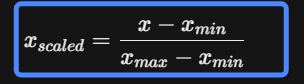

In [56]:
# import scalar
scalar = MinMaxScaler()

# fit the scalar on data
scaled_df = scalar.fit_transform(df)
scaled_df

# convert this data into panads dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.00,0.00,0.00
1,0.25,0.25,0.25
2,0.50,0.50,0.50
3,0.75,0.75,0.75
4,1.00,1.00,1.00


# 3. Max Absolute Scaler

In [57]:
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler

In [58]:
# make an example datsset
df = {
    'age': [25, 30, 35, 40, 45],
    'height': [165, 170, 175, 180, 185],
    'weight': [55, 60, 65, 70, 75]
}
df = pd.DataFrame(df)
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


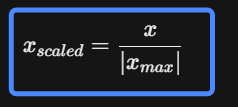

In [59]:
scalar = MaxAbsScaler()
# fit the scalar on data
scaled_df = scalar.fit_transform(df)

# convert this data into a panads dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.555556,0.891892,0.733333
1,0.666667,0.918919,0.800000
2,0.777778,0.945946,0.866667
3,0.888889,0.972973,0.933333
4,1.000000,1.000000,1.000000


# 4. Robust Scaler

In [60]:
import pandas as pd
from sklearn.preprocessing import RobustScaler


In [61]:
scalar = RobustScaler()
# fit the scalar on data
scaled_df = scalar.fit_transform(df)

# convert this data into a panads dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,1.0


# Transformation

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

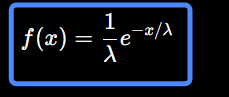

In [63]:
# generate non normal data (exponential distribution)
np.random.seed(0)  # start from position 0, 0 is simply starting point
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['value'])
df.head()


,value
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


In [64]:
df.min()

,0
value,0.001092


In [65]:
df.shape

(1000, 1)

<Axes: xlabel='value', ylabel='Count'>

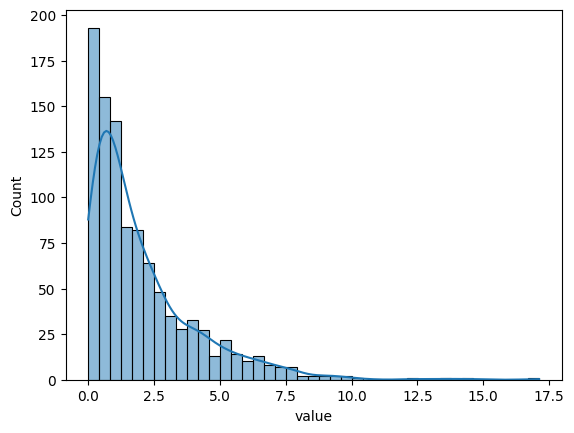

In [66]:
sns.histplot(df['value'], kde=True)

In [67]:
from sklearn.preprocessing import PowerTransformer
# Data must be positive for box-cox
pt_boxcox = PowerTransformer(method='box-cox')
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')

# take value column add 1 to every value and then apply box-cox and yeo_johnson transformation
df['Box_Cox'] = pt_boxcox.fit_transform(df[['value']] +1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['value']] +1)

In [68]:
df.head()

,value,Box_Cox,Yeo_Johnson
0,1.591749,0.179335,0.163651
1,2.511862,0.677331,0.685783
2,1.846446,0.339698,0.331474
3,1.574402,0.167607,0.151411
4,1.102097,-0.202107,-0.230634


<Axes: xlabel='value', ylabel='Count'>

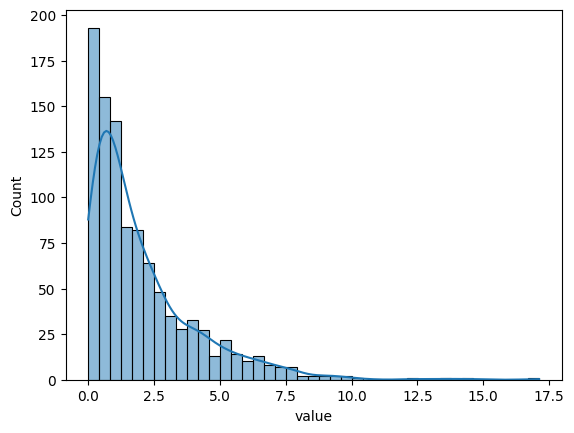

In [69]:
# create a histogram for all columns
sns.histplot(df['value'], kde=True)


<Axes: xlabel='Box_Cox', ylabel='Count'>

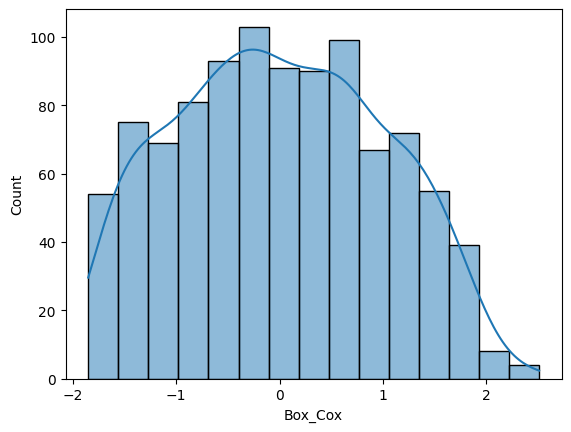

In [70]:
sns.histplot(df['Box_Cox'], kde=True)

<Axes: xlabel='Yeo_Johnson', ylabel='Count'>

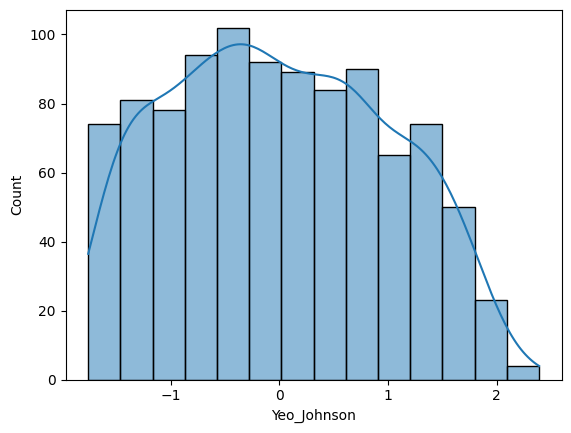

In [71]:
sns.histplot(df['Yeo_Johnson'], kde=True)

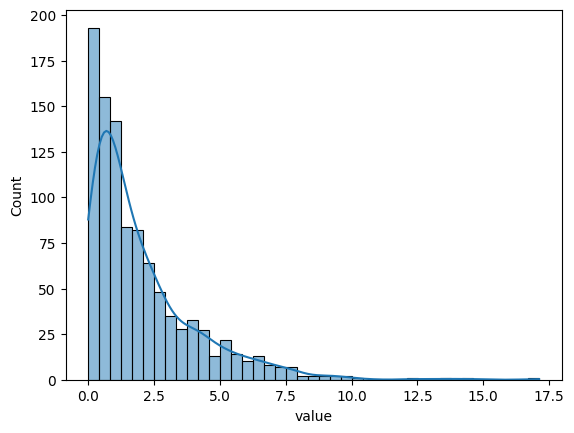

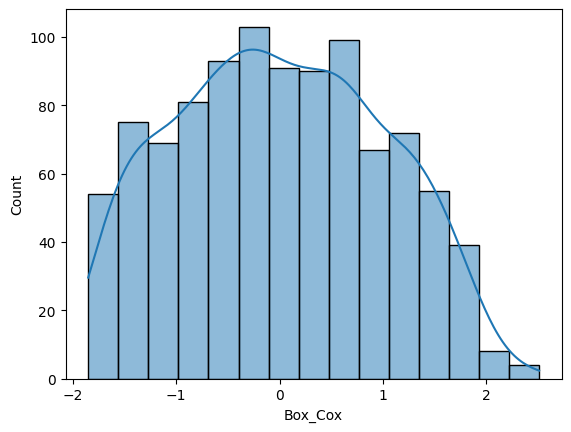

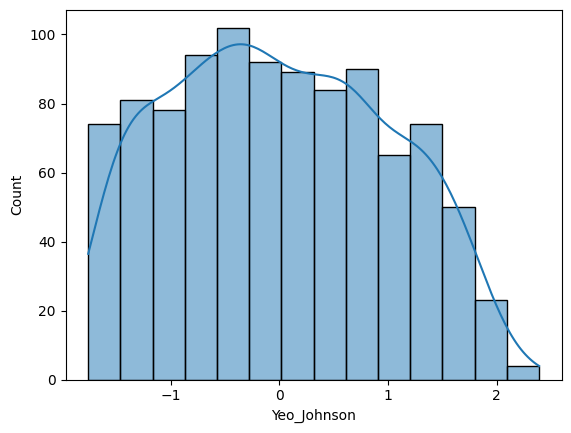

In [72]:
# by using for loop
for col in df.columns:
  sns.histplot(df[col], kde=True)
  plt.show()


# Quantile Transformer
* QuantileTransformer is another data transformation technique in scikit-learn
* It can transform skewed data into a more uniform or normal (Gaussian) distribution.

In [73]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer
# Data must be positive for box-cox
pt_boxcox = PowerTransformer(method='box-cox')
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')
qt_normal = QuantileTransformer(output_distribution='normal')

# take value column add 1 to every value and then apply box-cox and yeo_johnson transformation
df['Box_Cox'] = pt_boxcox.fit_transform(df[['value']] +1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['value']] +1)
df['Quantile'] = qt_normal.fit_transform(df[['value']])

In [74]:
df.head()

,value,Box_Cox,Yeo_Johnson,Quantile
0,1.591749,0.179335,0.163651,0.162552
1,2.511862,0.677331,0.685783,0.587964
2,1.846446,0.339698,0.331474,0.286135
3,1.574402,0.167607,0.151411,0.157469
4,1.102097,-0.202107,-0.230634,-0.154930


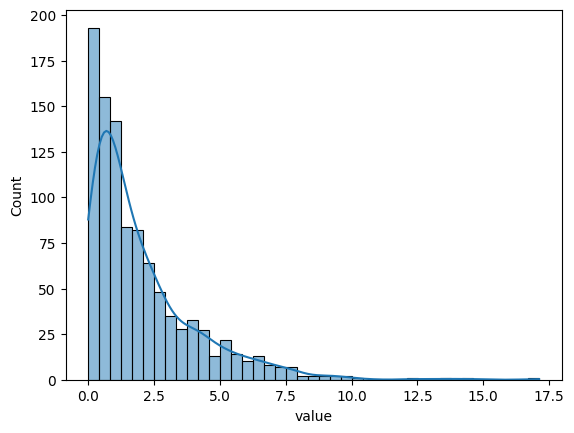

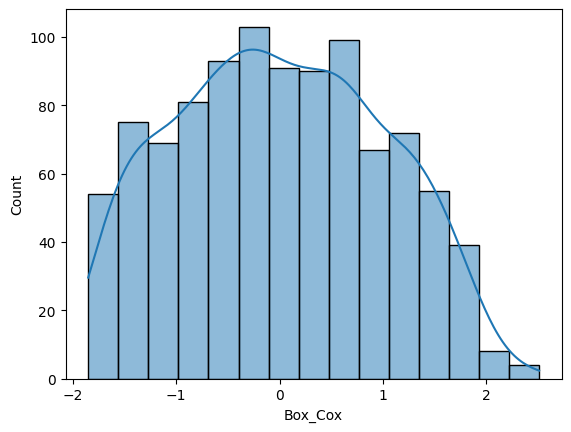

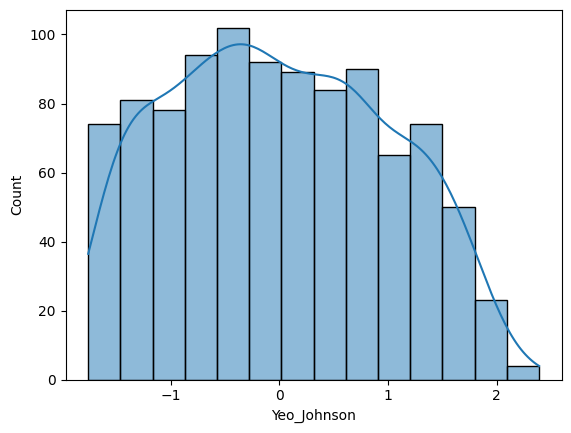

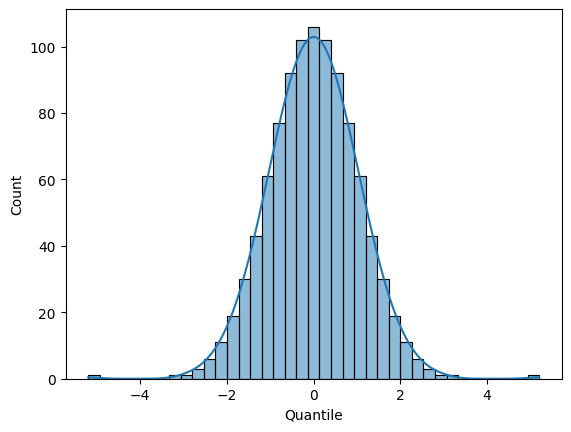

In [75]:
for col in df.columns:
  sns.histplot(df[col], kde=True)
  plt.show()

# Normalization

* Normalization means changing the values of data to a common/smaller range so that features can be compared more easily.
* Z-score normalization -> standard scaler
* Min-Max normalization -> Min-max scaler

# L2 normalization

* We scale all the values in one row/vector so that the total length (L2 norm) becomes 1.
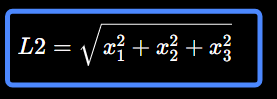
then
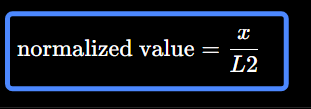

In [76]:
from sklearn.preprocessing import Normalizer
data = [[1, 1, 1], [1, 1, 0], [1, 0, 1]]
normalize = Normalizer(norm='l2')
print(normalize.fit_transform(data))

[[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [0.70710678 0.         0.70710678]]


# L1 normalization

* L1 normalization makes the sum of the absolute values in each row equal to 1.
* |3| + |4| = 3+4 = 7
* 3/7 = 0.4286
* 4/7 = 0.5714

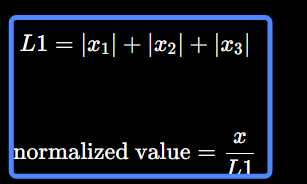

In [77]:
from sklearn.preprocessing import Normalizer
data = [[1, 1, 1], [1, 1, 0], [1, 0, 1]]
normalize = Normalizer(norm='l1')
print(normalize.fit_transform(data))

[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [0.5        0.         0.5       ]]


# Log Transformation

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns

# dataset with skewed values
df = {'Values': [1,5,10,20,50,100,1000,2000,3000,4000,50000,100000]}
df= pd.DataFrame(df)
df.head()

,Values
0,1
1,5
2,10
3,20
4,50


<Axes: xlabel='Values', ylabel='Count'>

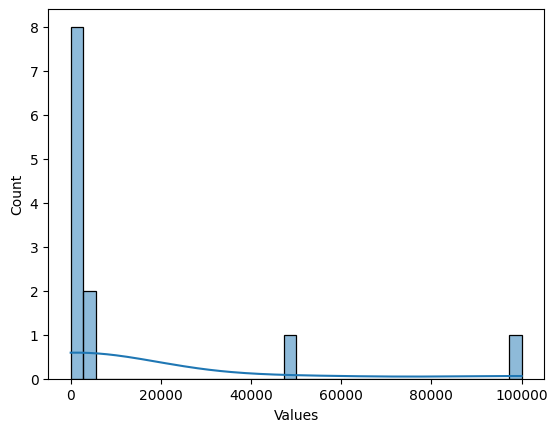

In [83]:
sns.histplot(df['Values'], kde=True)

In [85]:
df['log_values'] = np.log(df['Values'])
df

,Values,log_values
0,1,0.000000
1,5,1.609438
2,10,2.302585
3,20,2.995732
4,50,3.912023
5,100,4.605170
6,1000,6.907755
7,2000,7.600902
8,3000,8.006368
9,4000,8.294050


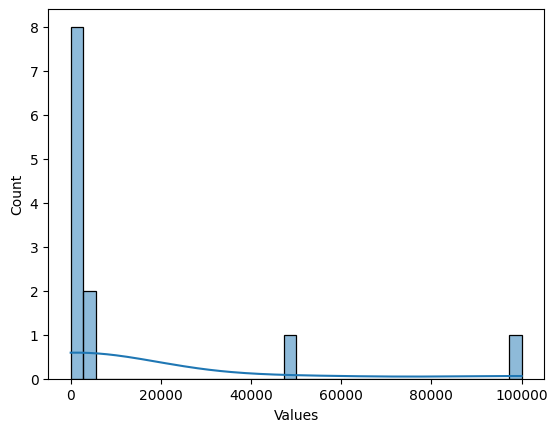

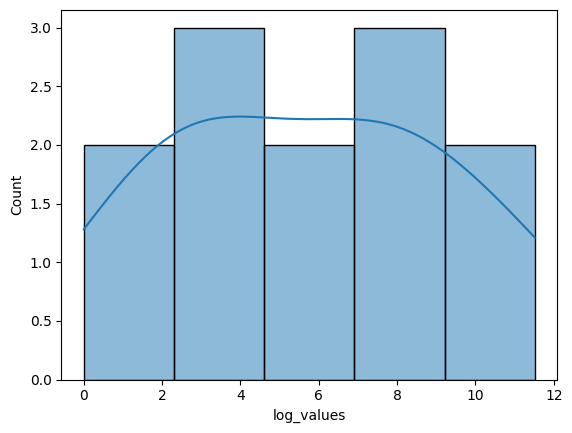

In [89]:
for col in df.columns:
  sns.histplot(df[col], kde=True)
  plt.show()